# Fit with a constraint on Bnw

In [1]:
# imports
from importlib import reload
import os, sys
import numpy as np

from matplotlib import pyplot as plt

import xarray
import pandas

from ocpy.pace import io as pace_io
from ocpy.utils import plotting

from bing.parameters import standard
from bing.models import utils as model_utils
from bing.priors import priors as bing_priors
from bing.fitting import inference as bing_inf
from bing import evaluate
from bing.fitting import chisq_fit
from bing import plotting as bing_plotting
from bing import evaluate

#
# Locals
sys.path.append(os.path.abspath("../../py"))
from grab_pace_granules import closest_Rrs
import biomass_io
import fitting

/home/xavier/miniforge3/envs/ocean14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Load

## Matched table

In [2]:
match_file = '../../matched_argo_bgc_profiles_bbp_v3.csv'
# Load up Argo profiles, already matched to PACE
matched = pandas.read_csv(match_file)

## Load by Argo profile

In [4]:
imatched = biomass_io.get_matched_profile(matched, 1902367, 11)
imatched

cruise                                                       1902367
filename                                                1902367QC.nc
profile                                                           11
lat                                                            3.709
lon                                                           88.955
time                             2025-05-31 09:39:59.999997952+00:00
solar_angle                                                34.158235
pace_ids           PACE_OCI_L2_AOP_PACE_OCI.20250601T070425.L2.OC...
closest_id         PACE_OCI_L2_AOP_PACE_OCI.20250601T070425.L2.OC...
closest_file              PACE_OCI.20250601T070425.L2.OC_AOP.V3_1.nc
closest_dist_km                                             0.734763
closest_time                        2025-06-01 07:06:54.500000+00:00
BING_Bnw                                                    0.000829
BING_Bnw_std                                                0.000205
BING_Bnw_lsig                     

## Load up closest spectrum from the existing fit

In [11]:
fit_file = biomass_io.get_fit_file_path(imatched)
d = biomass_io.load_fit_data(fit_file)
list(d.keys())

['chains',
 'LM',
 'wave',
 'Rrs',
 'Rrs_sig',
 'Rrs_idx',
 'lon',
 'lat',
 'dist',
 'med',
 'p14',
 'p86',
 'model_names']

In [13]:
d['wave'].shape

(10, 136)

## Grab the spectrum

In [14]:
items = [d['wave'][0], d['Rrs'][0], d['Rrs_sig'][0]]

# Plot the first one

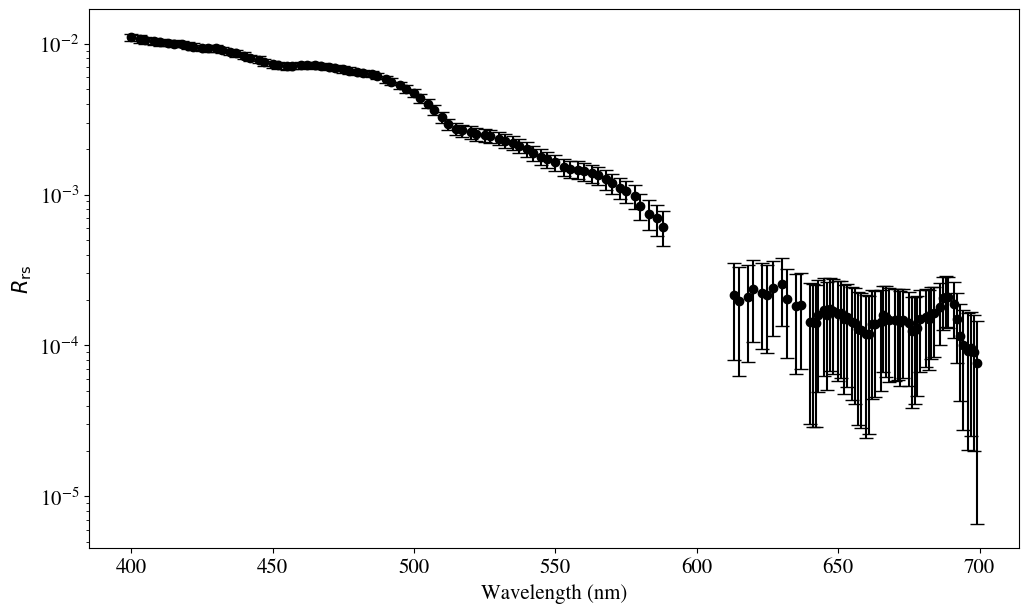

In [15]:
fig = plt.figure(figsize=(12,7))
ax = plt.gca()
#
ax.errorbar(items[0], items[1], yerr=items[2],
                color='k',  fmt='o', capsize=5) 
#
ax.set_yscale('log')
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel(r'$R_{\rm rs}$')
#
plotting.set_fontsize(ax, 15.)
#
plt.show()

# Fit it, standard

In [16]:
models_S, chains_S, ans_S, stats_S, rt_dict_S = fitting.fit_me(items)

----- Fitting with MCMC -----
idx=0
Running burn-in


  0%|                                                 | 0/1000 [00:00<?, ?it/s]/home/xavier/miniforge3/envs/ocean14/lib/python3.14/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|█████████████████████████████████████| 1000/1000 [00:05<00:00, 168.38it/s]


Running full model


100%|███████████████████████████████████| 40000/40000 [04:13<00:00, 157.69it/s]


In [17]:
a_mean_S, bb_mean_S, a_5_S, a_95_S, bb_5_S, bb_95_S,\
            model_Rrs_S, sigRs_S = evaluate.reconstruct_from_chains(
            models_S, chains_S, rt_dict_S)#, perc=perc)

## Plot me

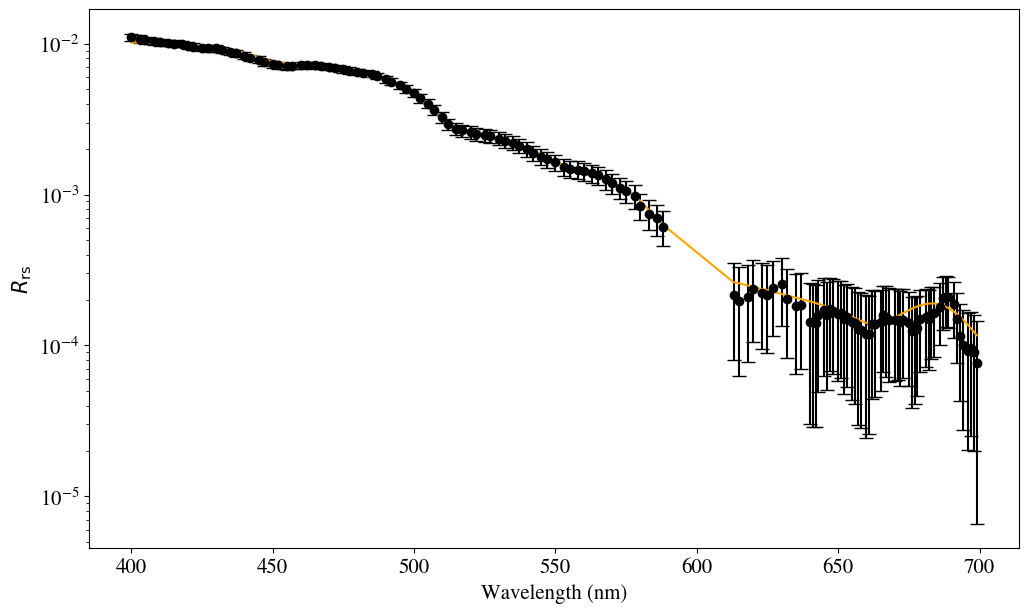

In [18]:
fig = plt.figure(figsize=(12,7))
ax = plt.gca()
#
ax.errorbar(items[0], items[1], yerr=items[2],
                color='k',  fmt='o', capsize=5) 
# Model Rrs
ax.plot(items[0], model_Rrs_S, color='orange')
#
ax.set_yscale('log')
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel(r'$R_{\rm rs}$')
#
plotting.set_fontsize(ax, 15.)
#
plt.show()

# Constrain Bnw from Argo

In [33]:
bpriors=[dict(flavor='log_uniform', pmin=-6, pmax=5)]*2

# Constrain by Argo
bpriors[0]=dict(flavor='gaussian', mean=np.log10(imatched.argo_bbp700), sigma=0.02, pmin=-6., pmax=5)

# Uniform for beta from 0. - 2. (positive here means negative slope)
bpriors[1]=dict(flavor='uniform', pmin=0., pmax=2.)

p = standard.expb_pow(satellite='PACE', add_noise=False,
            variable_Gordon=True, include_Raman=True, bpriors=bpriors,
            include_Chl_fl=True, phi_C=0.02, double_gaussian=True)
p.bpriors

[{'flavor': 'gaussian',
  'mean': np.float64(-3.192126867996668),
  'sigma': 0.02,
  'pmin': -6.0,
  'pmax': 5},
 {'flavor': 'uniform', 'pmin': 0.0, 'pmax': 2.0}]

## Fit

In [42]:
models_C, chains_C, ans_C, stats_C, rt_dict_C = fitting.fit_me(items, in_p=p)

----- Fitting with MCMC -----
idx=0
Running burn-in


  0%|                                                 | 0/1000 [00:00<?, ?it/s]/home/xavier/miniforge3/envs/ocean14/lib/python3.14/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|█████████████████████████████████████| 1000/1000 [00:06<00:00, 161.91it/s]


Running full model


100%|███████████████████████████████████| 40000/40000 [04:21<00:00, 153.24it/s]


In [45]:
stats_C

{'names': ['p0', 'p1', 'p2', 'p3', 'p4'],
 'med': array([-1.7168369 ,  0.01433134, -2.289387  , -3.1566794 ,  1.844905  ],
       dtype=float32),
 'p14': array([-1.7410451 ,  0.01295507, -2.375499  , -3.174529  ,  1.5812217 ],
       dtype=float32),
 'p86': array([-1.6941545 ,  0.01589915, -2.2185187 , -3.138642  ,  1.9652718 ],
       dtype=float32)}

In [46]:
stats_S

{'names': ['p0', 'p1', 'p2', 'p3', 'p4'],
 'med': array([-1.6910319,  0.0116167, -2.3735123, -3.0801053,  1.7011846],
       dtype=float32),
 'p14': array([-1.7204559 ,  0.01051233, -2.479693  , -3.1106648 ,  1.2540494 ],
       dtype=float32),
 'p86': array([-1.664297  ,  0.01315302, -2.2836204 , -3.0520532 ,  1.9310019 ],
       dtype=float32)}

In [43]:
a_mean_C, bb_mean_C, a_5_C, a_95_C, bb_5_C, bb_95_C,\
            model_Rrs_C, sigRs_C = evaluate.reconstruct_from_chains(
            models_C, chains_C, rt_dict_C)#, perc=perc)

### Plot

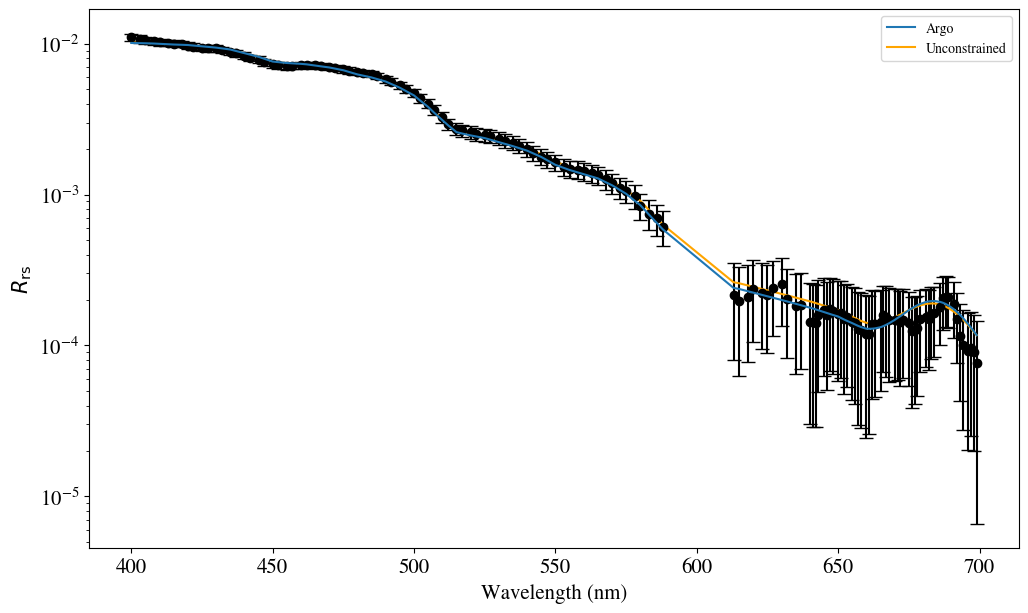

In [44]:
fig = plt.figure(figsize=(12,7))
ax = plt.gca()
#
ax.errorbar(items[0], items[1], yerr=items[2],
                color='k',  fmt='o', capsize=5) 
#ax.plot(models_V[0].wave, model_Rrs_V, label='Vanilla',zorder=10)
ax.plot(items[0], model_Rrs_C, label='Argo',zorder=20)
ax.plot(items[0], model_Rrs_S, color='orange', label='Unconstrained')

ax.set_yscale('log')
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel(r'$R_{\rm rs}$')
#
ax.legend()
plotting.set_fontsize(ax, 15.)
#
plt.show()

----

# Find the largest departures

In [3]:
reld = ((matched.BING_Bnw - matched.argo_bbp700) / matched.BING_Bnw).values

In [4]:
rsrt = np.argsort(reld)
reld[rsrt[-10]]

np.float64(0.9541882568089193)

In [5]:
idx = -25
matched.iloc[rsrt[idx]]

cruise                                                       5906537
filename                                                5906537QC.nc
profile                                                           85
lat                                                          -10.465
lon                                                           57.538
time                             2025-03-15 21:36:59.999998464+00:00
solar_angle                                               -66.959306
pace_ids           PACE_OCI_L2_AOP_PACE_OCI.20250315T084248.L2.OC...
closest_id         PACE_OCI_L2_AOP_PACE_OCI.20250315T084248.L2.OC...
closest_file              PACE_OCI.20250315T084248.L2.OC_AOP.V3_1.nc
closest_dist_km                                             0.396506
closest_time                               2025-03-15 08:45:18+00:00
BING_Bnw                                                    0.005359
BING_Bnw_std                                                0.001112
BING_Bnw_lsig                     

----

In [7]:
10**(-3.11)

0.0007762471166286919